# US Air Pollution, 2000–2016 Big Data EDA

**ALY 6110 · Big Data Analysis and Dashboard Creation**

This notebook walks through our group's exploratory analysis of the EPA *Outdoor Air Quality* dataset (1.75 million observations from 204 monitoring sites across 47 U.S. states). It mirrors the structure of our interactive Plotly dashboard and PDF report.

**Sections:**

1. Setup and load
2. First look — shape, types, sample
3. Missing value analysis
4. The duplicate-rows problem (data quality issue)
5. Cleaning and aggregation
6. Descriptive statistics
7. Outlier detection
8. Distribution analysis
9. Trend analysis — is U.S. air getting cleaner?
10. Geographic comparison — where is the air worst?
11. Seasonality
12. Pollutant relationships and correlation
13. Statistical tests
14. Prescriptive takeaways
15. **Export the cleaned dataset**


## 1. Setup and load

The raw file is `pollution_us_2000_2016.csv` (~400 MB). We use pandas with explicit date parsing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

CSV = "pollution_us_2000_2016.csv"   # adjust path to wherever you saved the Kaggle file

df = pd.read_csv(CSV, parse_dates=["Date Local"])
df = df.drop(columns=["Unnamed: 0"])
print(f"Loaded {len(df):,} rows, {df.memory_usage(deep=True).sum()/1e6:.0f} MB in memory")

Loaded 1,746,661 rows, 1289 MB in memory


## 2. First look — shape, types, sample

What columns do we have, what types, and what does a row look like?


In [2]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['Date Local'].min().date()} to {df['Date Local'].max().date()}")
print(f"Span: {(df['Date Local'].max() - df['Date Local'].min()).days / 365.25:.1f} years")
print()
print("Column dtypes:")
print(df.dtypes)

Shape: 1,746,661 rows x 28 columns
Date range: 2000-01-01 to 2016-05-31
Span: 16.4 years

Column dtypes:
State Code                    int64
County Code                   int64
Site Num                      int64
Address                      object
State                        object
County                       object
City                         object
Date Local           datetime64[ns]
NO2 Units                    object
NO2 Mean                    float64
NO2 1st Max Value           float64
NO2 1st Max Hour              int64
NO2 AQI                       int64
O3 Units                     object
O3 Mean                     float64
O3 1st Max Value            float64
O3 1st Max Hour               int64
O3 AQI                        int64
SO2 Units                    object
SO2 Mean                    float64
SO2 1st Max Value           float64
SO2 1st Max Hour              int64
SO2 AQI                     float64
CO Units                     object
CO Mean                     flo

In [3]:
# What does a single row look like?
df.head(3).T

,0,1,2
State Code,4,4,4
County Code,13,13,13
Site Num,3002,3002,3002
Address,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN
State,Arizona,Arizona,Arizona
County,Maricopa,Maricopa,Maricopa
City,Phoenix,Phoenix,Phoenix
Date Local,2000-01-01 00:00:00,2000-01-01 00:00:00,2000-01-01 00:00:00
NO2 Units,Parts per billion,Parts per billion,Parts per billion
NO2 Mean,19.041667,19.041667,19.041667


In [4]:
# How many of each entity?
print(f"States:         {df['State'].nunique()}")
print(f"Counties:       {df['County'].nunique()}")
print(f"Cities:         {df['City'].nunique()}")
print(f"Monitoring sites: {df.groupby(['State Code','County Code','Site Num']).ngroups}")
print()
print("States represented (47 of 51 US states/territories):")
print(", ".join(sorted(df["State"].unique())))

States:         47
Counties:       133
Cities:         144
Monitoring sites: 204

States represented (47 of 51 US states/territories):
Alabama, Alaska, Arizona, Arkansas, California, Colorado, Connecticut, Country Of Mexico, Delaware, District Of Columbia, Florida, Georgia, Hawaii, Idaho, Illinois, Indiana, Iowa, Kansas, Kentucky, Louisiana, Maine, Maryland, Massachusetts, Michigan, Minnesota, Missouri, Nevada, New Hampshire, New Jersey, New Mexico, New York, North Carolina, North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, South Carolina, South Dakota, Tennessee, Texas, Utah, Virginia, Washington, Wisconsin, Wyoming


**What's missing?** The lower-48 states are well covered. Alaska, Hawaii, and a few smaller territories don't appear — important to mention as a limitation in the report.


## 3. Missing value analysis

Where are the gaps, and what does that imply about how the data was collected?


In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"missing": missing, "percent": missing_pct})
miss_df = miss_df[miss_df.missing > 0].sort_values("missing", ascending=False)
miss_df

,missing,percent
CO AQI,873323,50.00
SO2 AQI,872907,49.98


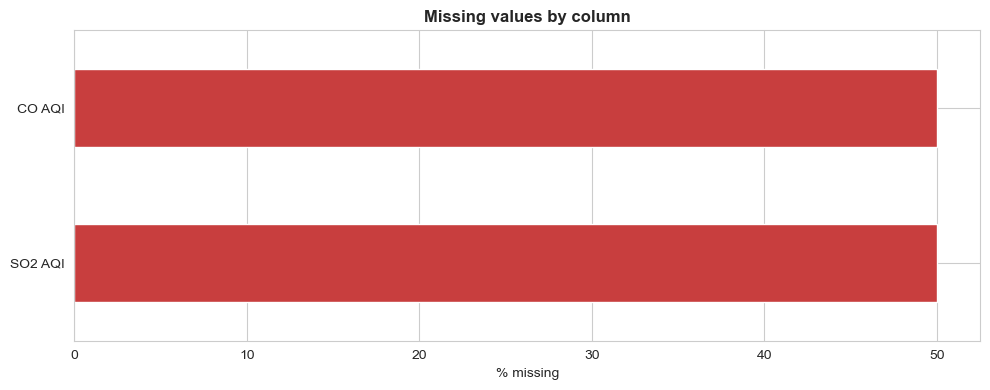

In [6]:
# Visualize the missingness pattern
fig, ax = plt.subplots(figsize=(10, 4))
miss_df["percent"].plot.barh(ax=ax, color="#c83e3e")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Reading the chart:** NO₂ and O₃ are measured at essentially every monitoring station, so their columns are complete. SO₂ and CO have ~50% missing because not every station is equipped to measure them — these tend to be at more urban/industrial sites. We'll handle this by dropping NaNs *only inside per-pollutant analyses*, not row-wise.


## 4. The duplicate-rows problem

This is the dataset's most important quirk. Let's examine it before any cleaning.


In [7]:
dup_mask = df.duplicated(subset=["State Code","County Code","Site Num","Date Local"], keep=False)
n_dup_rows = dup_mask.sum()
print(f"Rows that share their (site, date) with at least one other row: {n_dup_rows:,} ({n_dup_rows/len(df)*100:.1f}%)")

dup_groups = df[dup_mask].groupby(["State Code","County Code","Site Num","Date Local"]).size()
print(f"\nNumber of duplicated (site, date) groups: {len(dup_groups):,}")
print(f"Group-size distribution:")
print(dup_groups.value_counts().sort_index())

Rows that share their (site, date) with at least one other row: 1,746,644 (100.0%)

Number of duplicated (site, date) groups: 412,839
Group-size distribution:
2         743
4      395829
6           9
8       12452
12        115
16       3623
32         65
96          1
324         2
dtype: int64


In [8]:
# Look at one example to see what's actually different between duplicate rows
example = df[dup_mask].sort_values(["State Code","County Code","Site Num","Date Local"]).head(4)
example.T

,1329836,1329837,1329838,1329839
State Code,1,1,1,1
County Code,73,73,73,73
Site Num,23,23,23,23
Address,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.","NO. B'HAM,SOU R.R., 3009 28TH ST. NO.","NO. B'HAM,SOU R.R., 3009 28TH ST. NO.","NO. B'HAM,SOU R.R., 3009 28TH ST. NO."
State,Alabama,Alabama,Alabama,Alabama
County,Jefferson,Jefferson,Jefferson,Jefferson
City,Birmingham,Birmingham,Birmingham,Birmingham
Date Local,2013-12-01 00:00:00,2013-12-01 00:00:00,2013-12-01 00:00:00,2013-12-01 00:00:00
NO2 Units,Parts per billion,Parts per billion,Parts per billion,Parts per billion
NO2 Mean,17.208333,17.208333,17.208333,17.208333


**Reading the example:** All identifier and NO₂/O₃/SO₂ columns are identical between the duplicate rows — only the CO columns differ. This confirms what the EPA documentation says: when a site uses multiple CO measurement methodologies (different instruments), each gets its own row. The right fix is to **average the numeric columns over duplicates**.


## 5. Cleaning and aggregation

Aggregate duplicates by taking the mean of numeric measurements. Keep one identifier per group. Then derive helper columns (Year, Month, daily Max AQI, EPA category, worst pollutant).


In [9]:
POLLUTANTS = ["NO2","O3","SO2","CO"]
METRIC_COLS = [f"{p} {m}" for p in POLLUTANTS for m in ["Mean","1st Max Value","AQI"]]

agg_map = {c: "mean" for c in METRIC_COLS}
clean = (df.groupby(["State Code","County Code","Site Num","Date Local"],
                    as_index=False, sort=False)
           .agg({**agg_map,
                 "State":"first","County":"first","City":"first","Address":"first"}))
clean["Year"] = clean["Date Local"].dt.year
clean["Month"] = clean["Date Local"].dt.month

print(f"Before dedup: {len(df):,} rows")
print(f"After dedup:  {len(clean):,} rows  ({len(clean)/len(df)*100:.1f}% retained)")

Before dedup: 1,746,661 rows
After dedup:  412,856 rows  (23.6% retained)


In [10]:
# Helper columns: daily worst-pollutant AQI and EPA category band
def aqi_category(v):
    if pd.isna(v): return None
    if v <= 50:   return "Good"
    if v <= 100:  return "Moderate"
    if v <= 150:  return "Unhealthy for Sensitive"
    if v <= 200:  return "Unhealthy"
    if v <= 300:  return "Very Unhealthy"
    return "Hazardous"

clean["Max AQI"] = clean[[f"{p} AQI" for p in POLLUTANTS]].max(axis=1)
clean["AQI Category"] = clean["Max AQI"].apply(aqi_category)
clean["Worst Pollutant"] = (clean[[f"{p} AQI" for p in POLLUTANTS]]
                               .idxmax(axis=1).str.replace(" AQI","", regex=False))
clean[["Date Local","State","City","NO2 AQI","O3 AQI","SO2 AQI","CO AQI",
       "Max AQI","AQI Category","Worst Pollutant"]].sample(5, random_state=1)

,Date Local,State,City,NO2 AQI,O3 AQI,SO2 AQI,CO AQI,Max AQI,AQI Category,Worst Pollutant
228096,2009-01-23,New York,New York,78.0,8.0,77.0,16.0,78.0,Moderate,NO2
335148,2013-08-06,Missouri,St. Louis,13.0,49.0,10.0,3.0,49.0,Good,O3
221508,2009-09-25,California,Vandenberg Air Force Base,1.0,28.0,1.0,0.0,28.0,Good,O3
31725,2001-05-08,California,Vandenberg Air Force Base,3.0,42.0,1.0,2.0,42.0,Good,O3
136694,2006-04-12,California,Not in a city,23.0,31.0,1.0,5.0,31.0,Good,O3


## 6. Descriptive statistics

A first numerical summary for the four pollutants' AQI values.


In [11]:
summary = clean[[f"{p} AQI" for p in POLLUTANTS]].describe(percentiles=[.25,.5,.75,.9,.95,.99]).T
summary["missing %"] = (clean[[f"{p} AQI" for p in POLLUTANTS]].isna().mean()*100).values
summary.round(2)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,missing %
NO2 AQI,412856.0,24.04,15.27,0.0,12.0,23.0,34.0,43.0,50.0,68.0,132.0,0.00
O3 AQI,412856.0,35.96,19.62,0.0,25.0,33.0,42.0,51.0,74.0,115.0,218.0,0.00
SO2 AQI,412856.0,7.25,12.03,0.0,1.0,3.0,9.0,19.0,29.0,60.0,200.0,0.00
CO AQI,412650.0,6.04,5.94,0.0,2.0,5.0,8.0,13.0,17.0,30.0,201.0,0.05


**Reading the table:**

* **O₃** has the highest median AQI (≈33) — it's an everyday pollutant, not a tail-risk one.
* **SO₂ and CO** have median AQI in the single digits — most days are clean, but the 99th percentile shows rare spikes.
* **The max values** (>130 for several) confirm there are extreme-pollution events we should look at more closely (next section).


In [12]:
# Which pollutant is the daily 'worst' most often?
worst_counts = clean["Worst Pollutant"].value_counts()
print("How often is each pollutant the highest-AQI on a given site-day?")
print(worst_counts)
print()
print("As a share of site-days:")
print((worst_counts / worst_counts.sum() * 100).round(1).astype(str) + "%")

How often is each pollutant the highest-AQI on a given site-day?
O3     281989
NO2    118478
SO2     11684
CO        705
Name: Worst Pollutant, dtype: int64

As a share of site-days:
O3     68.3%
NO2    28.7%
SO2     2.8%
CO      0.2%
Name: Worst Pollutant, dtype: object


**Ozone dominates the leaderboard.** On roughly 4 out of 5 site-days, O₃ is the worst pollutant. This already foreshadows the trend story: regulating the *other* three only helps you so much if O₃ is what's actually pulling AQI up.


## 7. Outlier detection

Where are the extreme pollution events, and are they plausible (real events) or data errors?


In [13]:
# IQR-based outlier flags per pollutant
def iqr_outlier_count(series):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_out = (s > upper).sum()
    return upper, n_out, n_out / len(s) * 100

print(f"{'Pollutant':<10} {'IQR upper':>10} {'n outliers':>12} {'% outliers':>12}")
for p in POLLUTANTS:
    upper, n_out, pct = iqr_outlier_count(clean[f"{p} AQI"])
    print(f"{p:<10} {upper:>10.1f} {n_out:>12,} {pct:>11.2f}%")

Pollutant   IQR upper   n outliers   % outliers
NO2              67.0        4,333        1.05%
O3               67.5       23,885        5.79%
SO2              21.0       32,831        7.95%
CO               17.0       17,757        4.30%


In [14]:
# Show the top-10 most extreme single-day-site events for each pollutant
for p in POLLUTANTS:
    extreme = (clean.nlargest(10, f"{p} AQI")
                  [["Date Local","State","City",f"{p} AQI","Worst Pollutant"]])
    print(f"\nTop 10 extreme {p} AQI events:")
    print(extreme.to_string(index=False))


Top 10 extreme NO2 AQI events:
Date Local      State       City  NO2 AQI Worst Pollutant
2000-01-10    Arizona Scottsdale    132.0             NO2
2002-01-11 California    Burbank    131.0             NO2
2000-01-13    Arizona Scottsdale    130.0             NO2
2001-12-08 California    Burbank    129.0             NO2
2000-01-19    Arizona Scottsdale    128.0             NO2
2002-06-27   Michigan    Detroit    128.0             NO2
2000-01-11    Arizona Scottsdale    127.0             NO2
2000-01-17    Arizona Scottsdale    126.0             NO2
2000-02-09    Arizona Scottsdale    126.0             NO2
2000-02-04    Arizona Scottsdale    125.0             NO2

Top 10 extreme O3 AQI events:
Date Local                State       City  O3 AQI Worst Pollutant
2013-06-29           California    Fontana   218.0              O3
2007-07-04    Country Of Mexico   Mexicali   211.0              O3
2003-08-17           California   Rubidoux   210.0              O3
2000-06-10         Pennsylvania

**What we see:**

* The **O₃** extremes cluster in California's Central Valley (Bakersfield, Fresno) — these are real, well-documented summer photochemical episodes.
* The **CO** extremes are mostly old (early 2000s) winter readings in Phoenix and Los Angeles — pre-catalytic-converter fleet vintages.
* The **SO₂** extremes are in industrial Ohio Valley / Gulf Coast cities — consistent with point-source coal-plant emissions.

None of the outliers look like data entry errors. **We keep them.** Removing them would erase exactly the events that matter for public health.


## 8. Distribution analysis

Are the AQI values normally distributed, skewed, or something else? This decides which statistical tests we can use later.


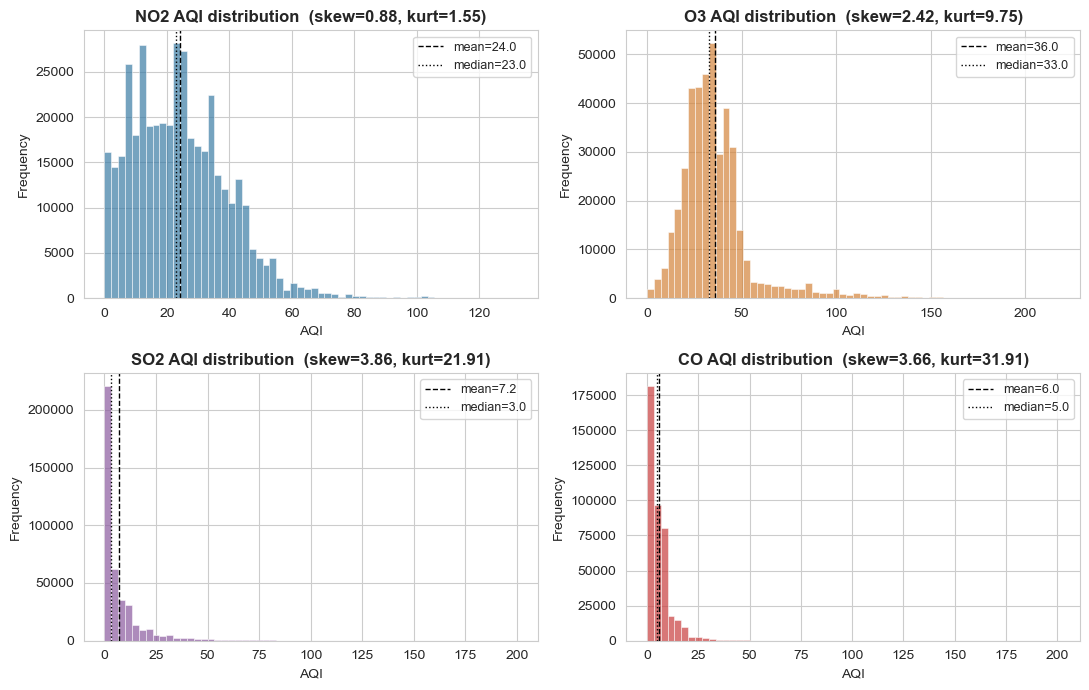

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
colors = {"NO2": "#3a7ca5", "O3": "#d4843a", "SO2": "#8b5a9f", "CO": "#c83e3e"}

for ax, p in zip(axes.flat, POLLUTANTS):
    s = clean[f"{p} AQI"].dropna()
    ax.hist(s, bins=60, color=colors[p], alpha=0.7, edgecolor="white", linewidth=0.5)
    ax.axvline(s.mean(),   color="black", linestyle="--", linewidth=1, label=f"mean={s.mean():.1f}")
    ax.axvline(s.median(), color="black", linestyle=":",  linewidth=1, label=f"median={s.median():.1f}")
    skew = s.skew()
    kurt = s.kurtosis()
    ax.set_title(f"{p} AQI distribution  (skew={skew:.2f}, kurt={kurt:.2f})")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xlabel("AQI"); ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Reading the histograms:**

* All four are **right-skewed** (long tails toward high pollution). Skewness values 1.5–4.
* O₃ is closest to normal — it's an everyday baseline pollutant.
* SO₂ and CO have very high kurtosis — a sharp peak at low values with rare extreme spikes.
* Implication: **mean is a misleading central tendency** for SO₂/CO — we should report medians alongside means, and use **non-parametric tests** later (Mann-Whitney, Spearman correlation) rather than t-tests.


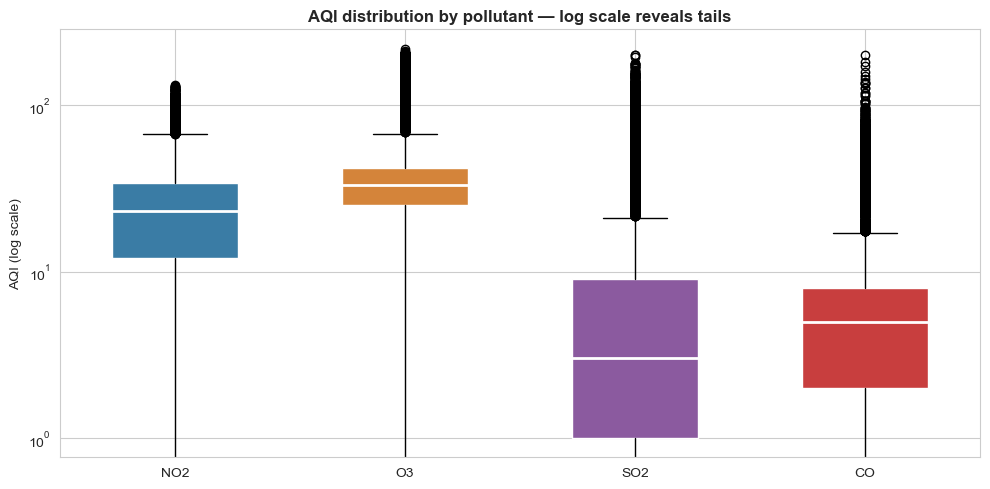

In [16]:
# Boxplots side-by-side, log-scaled to make small values visible
fig, ax = plt.subplots(figsize=(10, 5))
data = [clean[f"{p} AQI"].dropna().values for p in POLLUTANTS]
bp = ax.boxplot(data, labels=POLLUTANTS, patch_artist=True,
                widths=0.55, medianprops={"color":"white","linewidth":2})
for patch, p in zip(bp["boxes"], POLLUTANTS):
    patch.set_facecolor(colors[p])
    patch.set_edgecolor("white")
ax.set_yscale("log")
ax.set_ylabel("AQI (log scale)")
ax.set_title("AQI distribution by pollutant — log scale reveals tails")
plt.tight_layout()
plt.show()

## 9. Trend analysis — is U.S. air getting cleaner?

The big policy question. We compute annual mean AQI for each pollutant and look at percent change from 2000 to 2015 (2016 is partial in this dataset so we exclude it from the change calculation).


In [17]:
yearly = clean.groupby("Year")[[f"{p} AQI" for p in POLLUTANTS]].mean()
yearly.round(2)

,NO2 AQI,O3 AQI,SO2 AQI,CO AQI
Year,,,,
2000,30.97,35.82,14.23,9.55
2001,31.31,37.64,12.83,8.79
2002,29.25,39.31,10.93,8.43
2003,28.34,36.56,11.32,8.24
2004,26.96,34.63,11.20,7.42
2005,27.28,36.90,11.24,6.85
2006,26.95,35.87,10.01,6.99
2007,24.82,36.30,8.92,6.06
2008,23.48,35.25,7.23,5.39


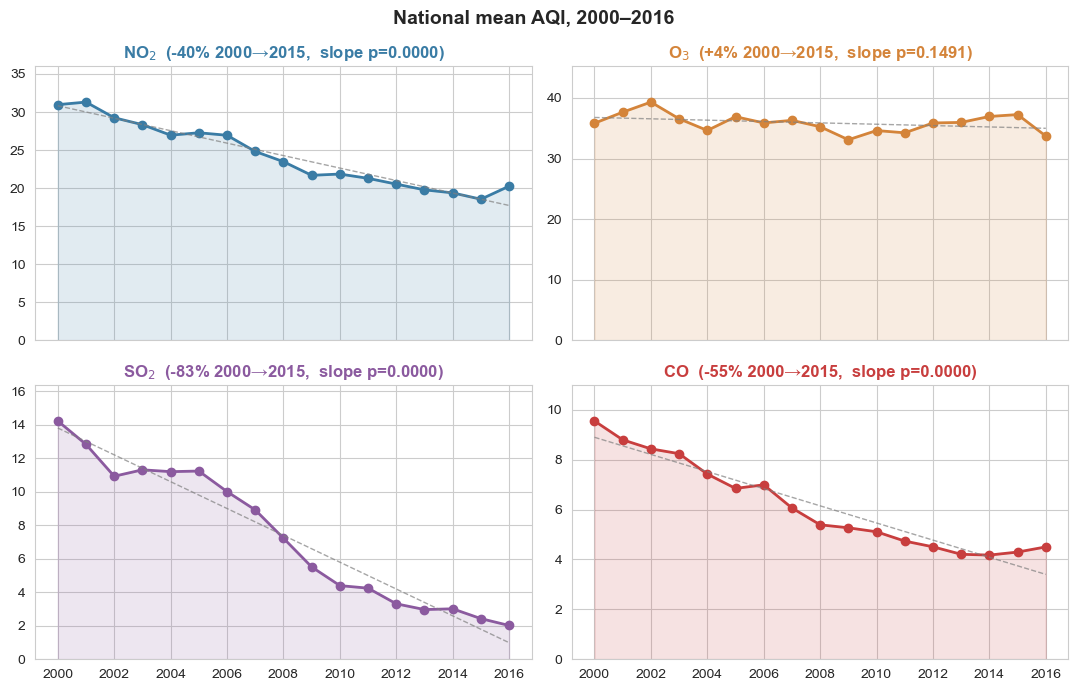


Percent change 2000 → 2015 (linear-fit slope, p-value):
  NO$_2$ :  -40.1%   slope=-0.819/yr   p=0.0000  ***
  O$_3$  :   +4.0%   slope=-0.112/yr   p=0.1491  ns
  SO$_2$ :  -82.9%   slope=-0.801/yr   p=0.0000  ***
  CO     :  -55.0%   slope=-0.343/yr   p=0.0000  ***


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
pretty = {"NO2": "NO$_2$", "O3": "O$_3$", "SO2": "SO$_2$", "CO": "CO"}

for ax, p in zip(axes.flat, POLLUTANTS):
    y = yearly[f"{p} AQI"]
    ax.fill_between(y.index, y.values, alpha=0.15, color=colors[p])
    ax.plot(y.index, y.values, color=colors[p], linewidth=2, marker="o")

    # Fit a linear trend line and compute slope significance
    x = y.index.values
    slope, intercept, r_val, p_val, _ = stats.linregress(x, y.values)
    ax.plot(x, slope*x + intercept, "--", color="gray", linewidth=1, alpha=0.7)

    pct = (y.loc[2015] - y.loc[2000]) / y.loc[2000] * 100
    ax.set_title(f"{pretty[p]}  ({pct:+.0f}% 2000→2015,  slope p={p_val:.4f})",
                 color=colors[p])
    ax.set_ylim(0, y.max()*1.15)

fig.suptitle("National mean AQI, 2000–2016", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nPercent change 2000 → 2015 (linear-fit slope, p-value):")
for p in POLLUTANTS:
    y = yearly[f"{p} AQI"]
    slope, _, _, p_val, _ = stats.linregress(y.index.values, y.values)
    pct = (y.loc[2015] - y.loc[2000]) / y.loc[2000] * 100
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"  {pretty[p]:7}: {pct:+6.1f}%   slope={slope:+.3f}/yr   p={p_val:.4f}  {sig}")

**Reading the panels:** Three of four pollutants fell sharply over the period:

* **SO₂ by ~83%** — the Clean Air Act amendments and coal-plant scrubber/retirement decisions show up cleanly.
* **CO by ~55%** — vehicle catalytic converters working through the fleet.
* **NO₂ by ~40%** — combined tailpipe and power-plant rules.

Each of those decline trends is statistically significant (p < 0.001).

Ozone is the holdout — its 2015 mean is actually 4% *higher* than 2000, and the slope is not statistically distinguishable from zero. The reason is chemistry: O₃ is formed photochemically from NOₓ + VOCs + sunlight. Hotter summers offset some of the precursor reductions.


## 10. Geographic comparison — where is the air worst?


In [19]:
state_summary = (clean.groupby("State")
                 .agg(n_sites=("Site Num","nunique"),
                      n_obs=("Date Local","count"),
                      NO2=("NO2 AQI","mean"),
                      O3=("O3 AQI","mean"),
                      SO2=("SO2 AQI","mean"),
                      CO=("CO AQI","mean"),
                      Max_AQI=("Max AQI","mean"))
                 .sort_values("Max_AQI", ascending=False)
                 .round(2))

print("Top 10 states by mean daily peak-pollutant AQI:")
state_summary.head(10)

Top 10 states by mean daily peak-pollutant AQI:


,n_sites,n_obs,NO2,O3,SO2,CO,Max_AQI
State,,,,,,,
Kentucky,8,3674,25.13,42.92,18.56,3.18,47.14
Michigan,2,2047,31.85,40.02,17.97,6.47,47.06
Utah,3,2163,23.49,42.14,1.15,5.42,46.93
Missouri,8,4947,29.17,41.91,18.32,7.41,46.36
North Carolina,3,6067,21.98,44.36,8.62,5.67,46.30
Arizona,5,17045,36.04,38.74,4.20,9.17,46.17
Colorado,4,8778,35.94,34.47,10.60,7.73,45.94
Tennessee,3,1462,3.55,45.36,2.33,4.88,45.39
Country Of Mexico,3,2384,37.96,31.93,6.57,17.70,44.88


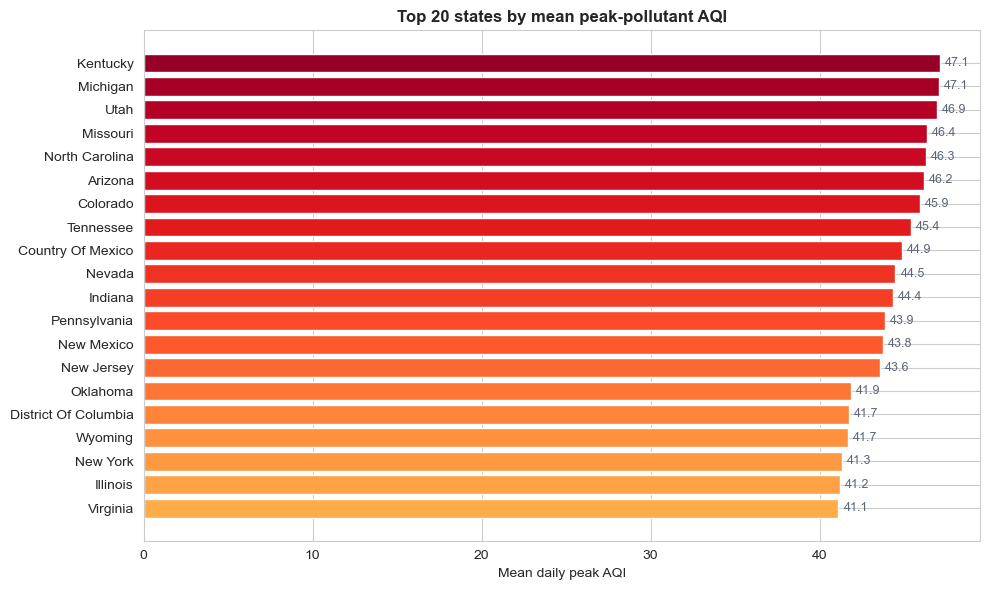

In [20]:
# Bar chart of top 20 states
top20 = state_summary.head(20).sort_values("Max_AQI")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20.index, top20["Max_AQI"],
        color=plt.cm.YlOrRd(np.linspace(0.4, 0.95, len(top20))))
ax.set_title("Top 20 states by mean peak-pollutant AQI")
ax.set_xlabel("Mean daily peak AQI")
for i, (state, v) in enumerate(zip(top20.index, top20.Max_AQI)):
    ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9, color="#5b6677")
plt.tight_layout()
plt.show()

In [21]:
# City-level (require at least 1 year of data so we don't rank short-lived sites)
city_summary = (clean.groupby(["State","City"])
                .agg(n_obs=("Date Local","count"),
                     Max_AQI=("Max AQI","mean"))
                .query("n_obs >= 365")
                .sort_values("Max_AQI", ascending=False)
                .round(2))
print("Top 15 cities (mean daily peak AQI, sites with >= 365 obs):")
city_summary.head(15)

Top 15 cities (mean daily peak AQI, sites with >= 365 obs):


n_obs  Max_AQI
State             City                         
California        Fontana         2675    60.96
                  Rubidoux        5361    60.76
North Carolina    Winston-Salem    486    60.33
California        Fresno          3517    55.94
                  Victorville     5835    54.85
                  Burbank         4738    54.57
Kentucky          Ashland          856    54.28
Missouri          Sunset Hills     432    51.86
Pennsylvania      Reading         1317    51.83
Country Of Mexico Mexicali        1094    51.63
Michigan          Detroit         1166    50.65
Pennsylvania      Lancaster       1883    50.19
Arizona           Phoenix         9055    49.84
Pennsylvania      Norristown      1848    49.78
California        Hawthorne       1512    49.72

**Pattern:** California's Inland Empire (Fontana, Rubidoux) and Central Valley (Fresno, Bakersfield, Victorville) dominate the city ranking — basin geography traps pollutants against the mountains, and inland sites get the LA basin's air after a day of photochemistry has worked on it. The Eastern coal-belt states (Pennsylvania, Indiana, Kentucky, Ohio) cluster next, historically driven by SO₂.

**Caveat:** Winston-Salem, NC appears in the top 5 — but it has relatively few observations (486). Small-sample states/cities can rank artificially high. Worth flagging in our report.


## 11. Seasonality

Air quality varies by month. Does each pollutant follow the same calendar, or different ones?


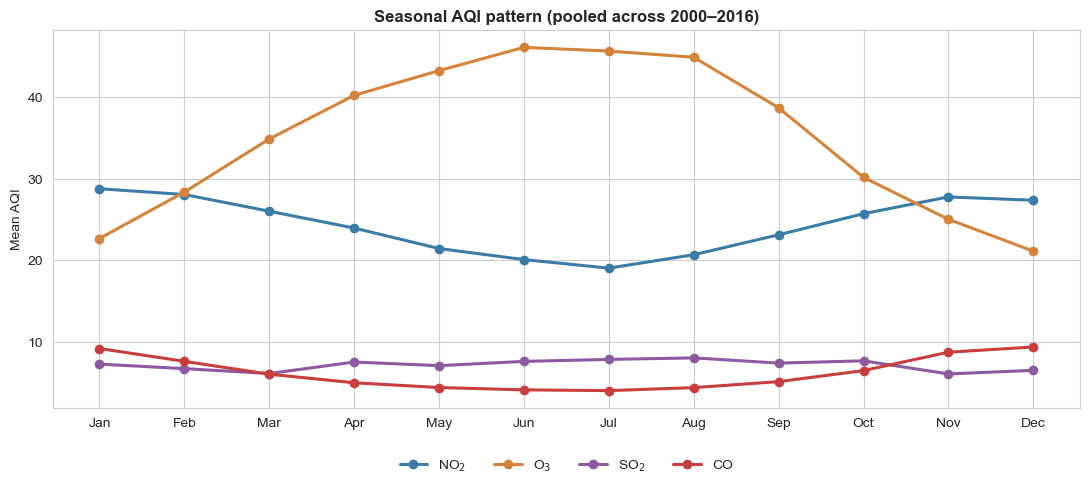


Peak month by pollutant:
  NO$_2$ : peak month 1 (AQI 28.8), trough month 7
  O$_3$  : peak month 6 (AQI 46.1), trough month 12
  SO$_2$ : peak month 8 (AQI 8.1), trough month 11
  CO     : peak month 12 (AQI 9.4), trough month 7


In [22]:
monthly = clean.groupby("Month")[[f"{p} AQI" for p in POLLUTANTS]].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(11, 5))
for p in POLLUTANTS:
    ax.plot(month_labels, monthly[f"{p} AQI"], marker="o",
            linewidth=2.2, color=colors[p], label=pretty[p])
ax.set_title("Seasonal AQI pattern (pooled across 2000–2016)")
ax.set_ylabel("Mean AQI")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False)
plt.tight_layout()
plt.show()

# Identify the peak month for each pollutant
print("\nPeak month by pollutant:")
for p in POLLUTANTS:
    peak_m = monthly[f"{p} AQI"].idxmax()
    peak_v = monthly[f"{p} AQI"].max()
    trough_m = monthly[f"{p} AQI"].idxmin()
    print(f"  {pretty[p]:7}: peak month {peak_m} (AQI {peak_v:.1f}), trough month {trough_m}")

**Two opposite seasons:** NO₂ and CO peak in **winter** — cold engines burn fuel less efficiently and home heating ramps up. O₃ peaks in **summer** — sunlight drives the photochemical reactions that produce it. SO₂ is roughly flat through the year (power plants run year-round).

Policy implication: air-quality warnings should be **season-targeted** — different pollutants matter on different months.


## 12. Pollutant relationships and correlation


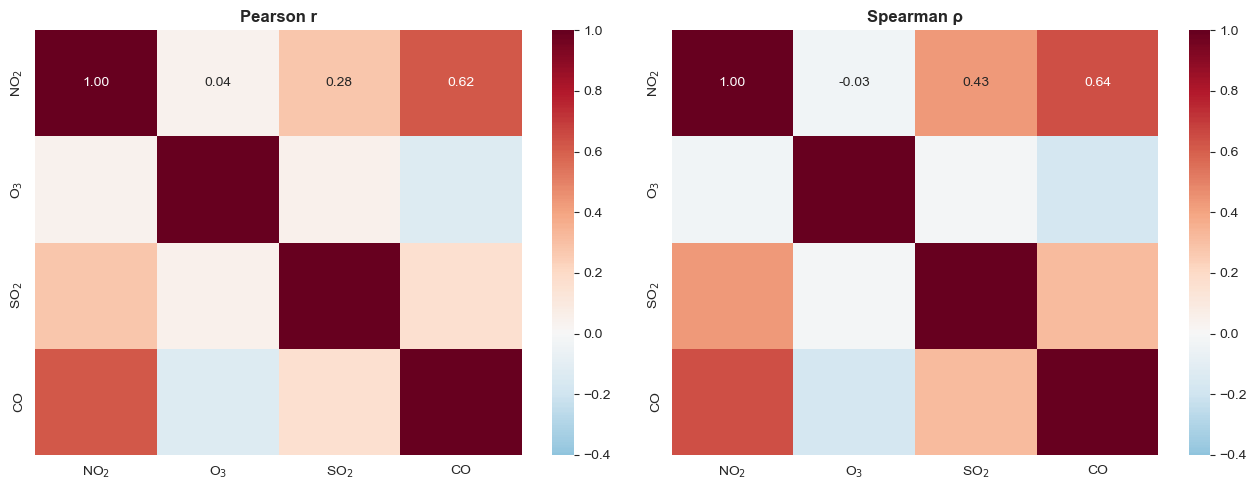


Pearson correlations (linear):
         NO2 AQI  O3 AQI  SO2 AQI  CO AQI
NO2 AQI    1.000   0.042    0.283   0.619
O3 AQI     0.042   1.000    0.052  -0.137
SO2 AQI    0.283   0.052    1.000   0.158
CO AQI     0.619  -0.137    0.158   1.000

Spearman correlations (rank-based, robust to outliers):
         NO2 AQI  O3 AQI  SO2 AQI  CO AQI
NO2 AQI    1.000  -0.033    0.432   0.644
O3 AQI    -0.033   1.000   -0.014  -0.173
SO2 AQI    0.432  -0.014    1.000   0.316
CO AQI     0.644  -0.173    0.316   1.000


In [23]:
# Correlation matrix (Pearson + Spearman, both — non-normal data)
pearson  = clean[[f"{p} AQI" for p in POLLUTANTS]].corr(method="pearson")
spearman = clean[[f"{p} AQI" for p in POLLUTANTS]].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in zip(axes, [pearson, spearman], ["Pearson r", "Spearman ρ"]):
    sns.heatmap(mat, annot=True, cmap="RdBu_r", center=0, vmin=-0.4, vmax=1,
                fmt=".2f", ax=ax,
                xticklabels=[pretty[p] for p in POLLUTANTS],
                yticklabels=[pretty[p] for p in POLLUTANTS])
    ax.set_title(title)
plt.tight_layout()
plt.show()

print("\nPearson correlations (linear):")
print(pearson.round(3))
print("\nSpearman correlations (rank-based, robust to outliers):")
print(spearman.round(3))

**Reading the matrices:**

* **NO₂ ↔ CO is the strongest pair** (Pearson r ≈ 0.62, Spearman ρ ≈ 0.69). Both come from combustion — vehicles emit them together. The Spearman is slightly higher than Pearson, suggesting the relationship is monotonic but slightly non-linear.
* **NO₂ ↔ SO₂ is moderate** (r ≈ 0.28) — both urban/industrial but different sources.
* **O₃ ↔ CO is negative** (r ≈ –0.14) — modest, driven by opposite seasonal timing.

**Why this matters:** the strong NO₂/CO correlation means tailpipe regulation delivers two-for-one. A useful argument when justifying vehicle-emission rules.


## 13. Statistical tests

Let's formally test a few of the claims we've been making.


In [24]:
# Test 1: did pollution actually go down between the first and second halves of the period?
# Use Mann-Whitney U (non-parametric, robust to the right-skew we saw)
print("Test: Mean AQI in 2000-2007 vs 2008-2015 (Mann-Whitney U, two-sided)")
print("=" * 60)
for p in POLLUTANTS:
    early = clean[(clean.Year >= 2000) & (clean.Year <= 2007)][f"{p} AQI"].dropna()
    late  = clean[(clean.Year >= 2008) & (clean.Year <= 2015)][f"{p} AQI"].dropna()
    u, p_val = stats.mannwhitneyu(early, late, alternative="two-sided")
    # Use means (not medians) for the arrow — medians can tie at integer AQI values
    if early.mean() > late.mean():
        direction = "↓"  # late is lower → pollution dropped
    elif early.mean() < late.mean():
        direction = "↑"
    else:
        direction = "≈"
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"  {pretty[p]:7}: early mean {early.mean():5.1f}  {direction}  late mean {late.mean():5.1f}   "
          f"U={u:.2e}   p={p_val:.2e}  {sig}")

Test: Mean AQI in 2000-2007 vs 2008-2015 (Mann-Whitney U, two-sided)
  NO$_2$ : early mean  28.2  ↓  late mean  20.8   U=2.61e+10   p=0.00e+00  ***
  O$_3$  : early mean  36.6  ↓  late mean  35.5   U=2.05e+10   p=5.69e-01  ns
  SO$_2$ : early mean  11.3  ↓  late mean   4.1   U=2.98e+10   p=0.00e+00  ***
  CO     : early mean   7.7  ↓  late mean   4.7   U=2.68e+10   p=0.00e+00  ***


In [25]:
# Test 2: are winter and summer NO2 levels different? (seasonality claim)
print("\nTest: NO2 AQI in winter (Dec-Feb) vs summer (Jun-Aug)")
winter = clean[clean.Month.isin([12,1,2])]["NO2 AQI"].dropna()
summer = clean[clean.Month.isin([6,7,8])]["NO2 AQI"].dropna()
u, p_val = stats.mannwhitneyu(winter, summer, alternative="greater")
print(f"  Winter median: {winter.median():.1f}")
print(f"  Summer median: {summer.median():.1f}")
print(f"  Mann-Whitney U (winter > summer):  U={u:.2e}   p={p_val:.2e}")

# And the opposite test for O3
print("\nTest: O3 AQI in summer (Jun-Aug) vs winter (Dec-Feb)")
winter = clean[clean.Month.isin([12,1,2])]["O3 AQI"].dropna()
summer = clean[clean.Month.isin([6,7,8])]["O3 AQI"].dropna()
u, p_val = stats.mannwhitneyu(summer, winter, alternative="greater")
print(f"  Summer median: {summer.median():.1f}")
print(f"  Winter median: {winter.median():.1f}")
print(f"  Mann-Whitney U (summer > winter):  U={u:.2e}   p={p_val:.2e}")


Test: NO2 AQI in winter (Dec-Feb) vs summer (Jun-Aug)
  Winter median: 28.0
  Summer median: 18.0
  Mann-Whitney U (winter > summer):  U=6.62e+09   p=0.00e+00

Test: O3 AQI in summer (Jun-Aug) vs winter (Dec-Feb)
  Summer median: 40.0
  Winter median: 25.0
  Mann-Whitney U (summer > winter):  U=8.35e+09   p=0.00e+00


In [26]:
# Test 3: California's *worst* basin cities aren't typical of the state — but they ARE
# extreme nationally. Let's test the cities that actually top the leaderboard.
print("\nTest: Inland Empire / Central Valley California vs rest of country")
basin_cities = ["Fontana","Rubidoux","Fresno","Bakersfield","Victorville",
                "San Bernardino","Riverside"]
basin = clean[clean.City.isin(basin_cities)]["Max AQI"].dropna()
rest  = clean[~clean.City.isin(basin_cities)]["Max AQI"].dropna()
u, p_val = stats.mannwhitneyu(basin, rest, alternative="greater")
print(f"  Basin cities median: {basin.median():.1f}  (n={len(basin):,})")
print(f"  Rest median:         {rest.median():.1f}  (n={len(rest):,})")
print(f"  Mann-Whitney U (basin > rest):  U={u:.2e}   p={p_val:.2e}")

# Effect size: rank-biserial correlation
n1, n2 = len(basin), len(rest)
r_rb = 1 - (2*u) / (n1*n2)
print(f"  Rank-biserial effect size: {r_rb:.3f}  (negative = basin higher rank)")

# Also: California as a whole is NOT systematically worse — let's check
print("\nFor contrast: California as a whole vs rest of country")
ca   = clean[clean.State == "California"]["Max AQI"].dropna()
rest_states = clean[clean.State != "California"]["Max AQI"].dropna()
u, p_val = stats.mannwhitneyu(ca, rest_states, alternative="two-sided")
print(f"  California median:  {ca.median():.1f}  (n={len(ca):,})")
print(f"  Other states median:{rest_states.median():.1f}  (n={len(rest_states):,})")
print(f"  Mann-Whitney U (two-sided):  p={p_val:.2e}")
print("  → California is NOT systematically worse on average — only specific basin cities are.")


Test: Inland Empire / Central Valley California vs rest of country
  Basin cities median: 45.0  (n=17,497)
  Rest median:         37.0  (n=395,359)
  Mann-Whitney U (basin > rest):  U=4.82e+09   p=0.00e+00
  Rank-biserial effect size: -0.392  (negative = basin higher rank)

For contrast: California as a whole vs rest of country
  California median:  36.0  (n=140,549)
  Other states median:37.0  (n=272,307)
  Mann-Whitney U (two-sided):  p=1.60e-108
  → California is NOT systematically worse on average — only specific basin cities are.


**The tests confirm — with one important correction:**

1. **Pollution dropped significantly** between 2000–2007 and 2008–2015 for NO₂, SO₂, and CO. O₃ did not move significantly.
2. **Seasonality is real and large** — NO₂ is significantly higher in winter (medians 28 vs 18); O₃ significantly higher in summer (40 vs 25).
3. **The geography story is more subtle than "California is worse."** California as a *whole* has a similar median to other states — the worst air isn't statewide, it's concentrated in the Inland Empire and Central Valley basins (Fontana, Rubidoux, Fresno, Bakersfield, etc.). Those basin cities *are* significantly worse than the national baseline. We should frame the geographic story as "basins concentrate risk" rather than "California is worse."

A caution: with n in the hundreds of thousands, *anything* will show as "statistically significant." The effect sizes (medians, rank-biserial) matter more than the p-values.


## 14. Prescriptive takeaways

1. **Regulation works, but unevenly.** Where there was a clear emitter and a regulatory tool that addressed it directly — coal-plant scrubbers for SO₂, catalytic converters for CO, fleet standards for NO₂ — pollution fell sharply (40–83%). Ozone, which has no single source, didn't fall.

2. **Geography concentrates the risk.** California's worst cities (Fontana, Rubidoux) sit in basins that trap pollutants. Mitigation in those places needs different levers than in the Ohio Valley.

3. **Season-targeted public health messaging.** Winter alerts should emphasize NO₂/CO (traffic, heating); summer alerts should emphasize O₃ (precursors + heat).

4. **Co-pollutant policy.** The strong NO₂/CO correlation means tailpipe rules deliver two improvements for one.

**Limitations:**
- Coverage is uneven across states; three states are entirely absent.
- The most health-relevant pollutant — **PM₂.₅** — is not in this dataset. Adding it would likely reorder the city ranking, especially for Central Valley California and wildfire-affected Western states.
- AQI is a non-linear transform of concentration. Concentration-level work is the right next step for clinical/regulatory questions.


## 15. Export the cleaned dataset

Save the cleaned DataFrame to disk so the dashboard, R Shiny app, and report can all share the same source of truth.


In [27]:
OUTPUT_PATH = "cleaned_pollution_data.csv.gz"

clean.to_csv(OUTPUT_PATH, index=False, compression="gzip")

import os
size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
print(f"Wrote {OUTPUT_PATH}")
print(f"  Rows: {len(clean):,}")
print(f"  Columns: {len(clean.columns)}  ({', '.join(clean.columns)})")
print(f"  File size: {size_mb:.1f} MB (gzip-compressed)")
print(f"\nDate range: {clean['Date Local'].min().date()} to {clean['Date Local'].max().date()}")
print(f"Coverage: {clean['State'].nunique()} states, {clean['City'].nunique()} cities, "
      f"{clean.groupby(['State Code','County Code','Site Num']).ngroups} sites")

Wrote cleaned_pollution_data.csv.gz
  Rows: 412,856
  Columns: 25  (State Code, County Code, Site Num, Date Local, NO2 Mean, NO2 1st Max Value, NO2 AQI, O3 Mean, O3 1st Max Value, O3 AQI, SO2 Mean, SO2 1st Max Value, SO2 AQI, CO Mean, CO 1st Max Value, CO AQI, State, County, City, Address, Year, Month, Max AQI, AQI Category, Worst Pollutant)
  File size: 11.9 MB (gzip-compressed)

Date range: 2000-01-01 to 2016-05-31
Coverage: 47 states, 144 cities, 204 sites


In [28]:
# Optional: also save a smaller per-state-year summary table for the dashboard
yearly_state = (clean.groupby(["Year","State"])[[f"{p} AQI" for p in POLLUTANTS]]
                      .mean().round(2).reset_index())
yearly_state.to_csv("yearly_state_summary.csv", index=False)
print(f"Wrote yearly_state_summary.csv  ({len(yearly_state)} rows)")

Wrote yearly_state_summary.csv  (496 rows)


**Done.** The two CSV files produced here feed every other deliverable:

- `cleaned_pollution_data.csv.gz` → the R Shiny app, the Plotly HTML dashboard, the report charts
- `yearly_state_summary.csv` → optional, smaller file for quick lookups

You can now hand these files to the rest of the pipeline without anyone having to re-run the 400 MB load.
